In [2]:
#IMPORT LIBRARIES


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Import & Shape Analysis
df = pd.read_csv('ecommerce_customer_data_large.csv')
print(df.head())

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        44605  2023-05-03 21:30:02             Home            177         1   
1        44605  2021-05-16 13:57:44      Electronics            174         3   
2        44605  2020-07-13 06:16:57            Books            413         1   
3        44605  2023-01-17 13:14:36      Electronics            396         3   
4        44605  2021-05-01 11:29:27            Books            259         4   

   Total Purchase Amount Payment Method  Customer Age  Returns Customer Name  \
0                   2427         PayPal            31      1.0   John Rivera   
1                   2448         PayPal            31      1.0   John Rivera   
2                   2345    Credit Card            31      1.0   John Rivera   
3                    937           Cash            31      0.0   John Rivera   
4                   2598         PayPal            31      1.0   John Rivera   

   Age  Gender  Churn  
0   31  

In [21]:
print(df.shape)

(250000, 13)


In [51]:
print(df.dtypes)


Customer ID                int64
Purchase Date             object
Product Category          object
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method            object
Customer Age               int64
Returns                  float64
Customer Name             object
Age                        int64
Gender                    object
Churn                      int64
dtype: object


In [39]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


In [41]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB
None


In [5]:
print(df.describe())


         Customer ID  Product Price       Quantity  Total Purchase Amount  \
count  250000.000000  250000.000000  250000.000000          250000.000000   
mean    25017.632092     254.742724       3.004936            2725.385196   
std     14412.515718     141.738104       1.414737            1442.576095   
min         1.000000      10.000000       1.000000             100.000000   
25%     12590.000000     132.000000       2.000000            1476.000000   
50%     25011.000000     255.000000       3.000000            2725.000000   
75%     37441.250000     377.000000       4.000000            3975.000000   
max     50000.000000     500.000000       5.000000            5350.000000   

        Customer Age        Returns            Age         Churn  
count  250000.000000  202618.000000  250000.000000  250000.00000  
mean       43.798276       0.500824      43.798276       0.20052  
std        15.364915       0.500001      15.364915       0.40039  
min        18.000000       0.000000   

In [25]:
# Data Cleaning & Preprocessing

In [29]:
# check duplicate rows

duplicates = df.duplicated()
print("total duplicates:",duplicates.sum())

total duplicates: 0


In [31]:
# show duplicate entries (if any)

print(df[df.duplicated()])

Empty DataFrame
Columns: [Customer ID, Purchase Date, Product Category, Product Price, Quantity, Total Purchase Amount, Payment Method, Customer Age, Returns, Customer Name, Age, Gender, Churn]
Index: []


In [35]:
# drop duplicates

df.drop_duplicates(inplace=True)
print("After dropping duplicates:",df.duplicated().sum())

After dropping duplicates: 0


In [37]:
# check missing values

print(df.isnull().sum())

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [6]:
# fill missing values with 0

df.fillna(0,inplace=True)
print("after filling missing values",df.isnull().sum())

after filling missing values Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64


In [9]:
df.to_csv("cleaned_ecommerce.csv",index=False)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                250000 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [61]:
# Categorical overview


for col in ['Gender', 'Payment Method', 'Product Category']:
    print(f"{col}:", df[col].unique())


Gender: ['Female' 'Male']
Payment Method: ['Paypal' 'Credit Card' 'Cash']
Product Category: ['Home' 'Electronics' 'Books' 'Clothing']


In [55]:
# datetime conversion

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])


In [63]:

df['Payment Method'] = df['Payment Method'].str.title()
df['Gender'] = df['Gender'].str.title()


In [65]:
print(df.dtypes)


Customer ID                       int64
Purchase Date            datetime64[ns]
Product Category                 object
Product Price                     int64
Quantity                          int64
Total Purchase Amount             int64
Payment Method                   object
Customer Age                      int64
Returns                         float64
Customer Name                    object
Age                               int64
Gender                           object
Churn                             int64
dtype: object


In [ ]:
# Exploratory Data Analysis (EDA)

<Axes: xlabel='Customer Age', ylabel='Count'>

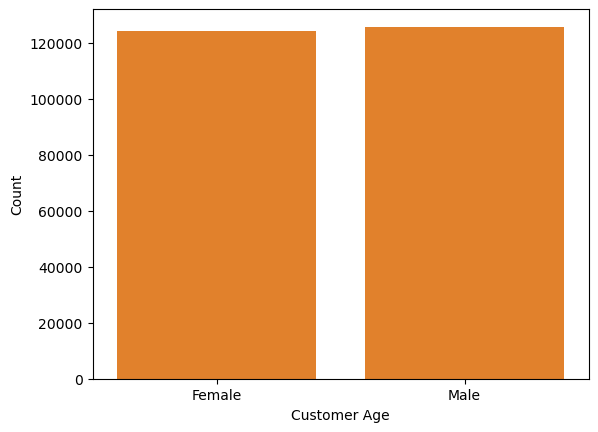

In [67]:
# Age Distribution & Gender Breakdown

sns.histplot(df['Customer Age'], kde=True)
sns.countplot(x='Gender', data=df)

<Axes: xlabel='Product Category', ylabel='Total Purchase Amount'>

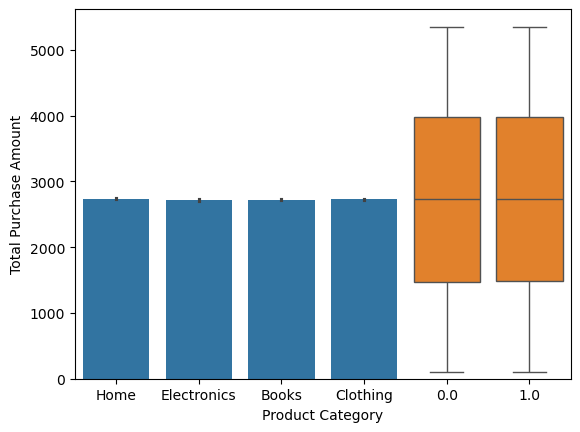

In [71]:
# Category Sales vs. Returns
sns.barplot(x='Product Category', y='Total Purchase Amount', data=df)
sns.boxplot(x='Returns', y='Total Purchase Amount', data=df)


<Axes: xlabel='Purchase Date'>

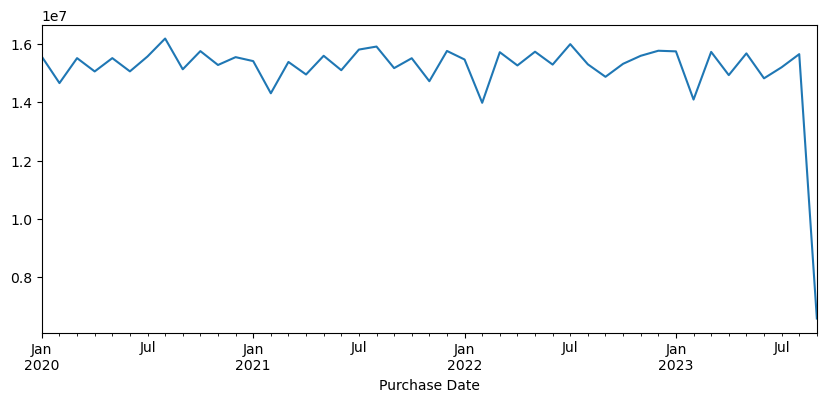

In [77]:
# Time Series Sales Trends

monthly_sales = df.resample('ME', on='Purchase Date')['Total Purchase Amount'].sum()
monthly_sales.plot(figsize=(10,4))


In [85]:
# Return Rate:
return_rate = df['Returns'].mean()
print(return_rate)

0.405904


In [91]:
# Average Spend per Customer:
avg_spend = df.groupby('Customer ID')['Total Purchase Amount'].sum().mean()
print(avg_spend)

13719.947222166287


In [95]:
# Churn Rate by Gender:
churn_gender = df.groupby('Gender')['Churn'].mean()
print(churn_gender)


Gender
Female    0.201626
Male      0.199426
Name: Churn, dtype: float64


In [99]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


In [1]:
# train_model.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

# Load dataset
df = pd.read_csv('C:\\Users\\Dhusyath\\Downloads\\PROJECTS_DA\\PROJECTS_DA\\ecommerce_customer_data_large.csv')

# Drop irrelevant columns
df = df.drop(columns=["Customer ID", "Purchase Date", "Customer Name"])

# Encode categorical variables
label_encoders = {}
for col in ["Product Category", "Payment Method", "Gender"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save model and encoders
joblib.dump(model, "churn_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(X.columns.tolist(), "feature_names.pkl")


['feature_names.pkl']